# Figura tipo 1C multi-referencia para muestras metagenómicas de *Saccharomyces*

Este notebook analiza las tablas `*.10kb_similarity.csv` generadas por tu pipeline de ventanas de 10 kb.

La lógica general es:

```text
BAM filtrado + VCF filtrado
↓
ventanas de 10 kb
↓
N_sites, SNPs_d, divergence, similarity
↓
figuras y resúmenes por referencia/muestra
```

La métrica `similarity_N_over_dplus1` está inspirada en la Figura 1C del artículo *High-Resolution Mapping of Complex Traits with a Four-Parent Advanced Intercross Yeast Population*:

```text
similarity = N / (d + 1)
```

donde:

- `N` = número de sitios comparables en una ventana
- `d` = número de diferencias de un solo nucleótido

En tu adaptación:

- cada muestra metagenómica se compara contra varias referencias
- cada referencia se analiza por separado
- los resultados se resumen por ventana, por cromosoma, por muestra y por referencia

## 1. Instalar librerías

Este notebook usa:

- `pandas` para leer y resumir tablas
- `matplotlib` para hacer figuras

En Colab normalmente ya están instaladas, pero esta celda asegura que estén disponibles.

In [ ]:
!pip -q install pandas matplotlib

## 2. Conectar Google Drive

Colab no puede leer directamente los archivos de tu cluster.  
Por eso, los resultados de `results_by_ref/` deben estar copiados a Google Drive.

Estructura esperada:

```text
MyDrive/yeast/results_by_ref/
├── AAR/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
├── ADE/
│   └── windows_10kb/
│       ├── SRR27931704.10kb_similarity.csv
│       └── ...
└── ...
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls drive/MyDrive/yeast/results_by_ref/

AAR/  sake/  scer/  SGD_2010/  ZP568s1/


## 3. Configuración general

Edita estas rutas si tus resultados están en otra carpeta.

Parámetros importantes:

- `RESULTS_ROOT`: carpeta principal con resultados separados por referencia
- `OUTPUT_DIR`: carpeta donde se guardarán figuras y tablas resumen
- `MIN_N_SITES`: mínimo de sitios comparables por ventana
- `MAX_SAMPLES_TO_PLOT`: limita cuántas muestras se grafican para evitar figuras saturadas

In [ ]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt

# Carpeta con resultados por referencia
RESULTS_ROOT = '/content/drive/MyDrive/yeast/results_by_ref'

# Carpeta de salida para figuras y tablas resumen
OUTPUT_DIR = '/content/drive/MyDrive/yeast/figures_1C_multi_ref'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filtro mínimo de sitios comparables por ventana
MIN_N_SITES = 10

# Si tienes muchas muestras, puedes limitar el número graficado.
# Usa None para graficar todas.
MAX_SAMPLES_TO_PLOT = None

print('RESULTS_ROOT:', RESULTS_ROOT)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('MIN_N_SITES:', MIN_N_SITES)
print('MAX_SAMPLES_TO_PLOT:', MAX_SAMPLES_TO_PLOT)

RESULTS_ROOT: /content/drive/MyDrive/yeast/results_by_ref
OUTPUT_DIR: /content/drive/MyDrive/yeast/figures_1C_multi_ref
MIN_N_SITES: 10
MAX_SAMPLES_TO_PLOT: None


## 4. Detectar referencias disponibles

Cada subcarpeta dentro de `RESULTS_ROOT` se interpreta como una referencia.

Ejemplo:

```text
results_by_ref/AAR/
results_by_ref/ADE/
results_by_ref/SGD_2010/
```

El nombre de la carpeta se usa como nombre de referencia.

In [ ]:
ref_dirs = sorted([
    d for d in glob.glob(os.path.join(RESULTS_ROOT, '*'))
    if os.path.isdir(d)
])

references = [os.path.basename(d) for d in ref_dirs]

print(f'Referencias encontradas: {len(references)}')
print(references)

Referencias encontradas: 5
['AAR', 'SGD_2010', 'ZP568s1', 'sake', 'scer']


In [ ]:
ls $RESULTS_ROOT/SGD_2010/windows_10kb

Scerevisiae_10pct_NO.10kb_similarity.csv
Scerevisiae_window_mutated_10pct.10kb_similarity.csv


## 5. Funciones auxiliares

Estas funciones hacen tres cosas:

1. ordenar cromosomas correctamente (`chr1`, `chr2`, ..., `chr16`)
2. cargar todas las tablas de una referencia
3. preparar los datos para análisis y figuras

Columnas esperadas en cada CSV:

- `sample`
- `chrom`
- `start`
- `end`
- `N_sites`
- `SNPs_d`
- `divergence_d_over_N`
- `similarity_N_over_dplus1`

Significado:

- `N_sites`: posiciones comparables dentro de una ventana
- `SNPs_d`: SNPs detectados en esa ventana
- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: sitios comparables por diferencia, inspirado en la Figura 1C

In [ ]:
def natural_chr_key(chrom):
    # Ordena cromosomas de forma biológica.
    # Funciona con nombres como chr1, chr10, chr1_AAR, chr12_ADE, chrI, chrII.
    chrom = str(chrom)

    # Caso numérico: chr1, chr2, chr10, chr1_AAR
    match = re.search(r'chr(\d+)', chrom, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))

    # Caso romano: chrI, chrII, chrXVI
    c = chrom.replace('chr', '').replace('Chr', '').split('_')[0]
    roman_map = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4,
        'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8,
        'IX': 9, 'X': 10, 'XI': 11, 'XII': 12,
        'XIII': 13, 'XIV': 14, 'XV': 15, 'XVI': 16
    }

    if c in roman_map:
        return roman_map[c]

    # Si no reconoce el formato, lo manda al final
    return 999


def load_reference_tables(ref_name):
    # Carga todos los CSV de ventanas de 10 kb para una referencia.
    #
    # Busca archivos en:
    # RESULTS_ROOT/ref_name/windows_10kb/*.10kb_similarity.csv
    #
    # Devuelve un DataFrame con todas las muestras de esa referencia.

    input_dir = os.path.join(RESULTS_ROOT, ref_name, 'windows_10kb')
    files = sorted(glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv')))

    if not files:
        raise FileNotFoundError(f'No CSVs found in {input_dir}')

    dfs = []

    for f in files:
        df = pd.read_csv(f)

        # Si el archivo no trae columna sample, la inferimos desde el nombre
        if 'sample' not in df.columns:
            df['sample'] = os.path.basename(f).replace('.10kb_similarity.csv', '')

        # Agregamos la referencia para comparar después
        df['reference'] = ref_name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Convertir columnas numéricas
    numeric_cols = [
        'start', 'end', 'N_sites', 'SNPs_d',
        'divergence_d_over_N', 'similarity_N_over_dplus1'
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    # Filtrar ventanas con poca información
    out = out[out['N_sites'] >= MIN_N_SITES].copy()

    # Posición inicial en megabases para que el eje X sea más legible
    out['start_mb'] = out['start'] / 1e6

    return out

## 6. Verificación rápida de datos

Esta celda revisa cuántos archivos de ventanas existen por referencia.

Si una referencia aparece con `0` archivos, significa que:

- no corriste `02_run_similarity_tables_multi_ref.sh` para esa referencia
- o no copiaste los resultados a Google Drive
- o la ruta `RESULTS_ROOT` está mal

In [ ]:
file_counts = []

for ref in references:
    input_dir = os.path.join(RESULTS_ROOT, ref, 'windows_10kb')
    files = glob.glob(os.path.join(input_dir, '*.10kb_similarity.csv'))
    file_counts.append({'reference': ref, 'n_csv_files': len(files)})

file_counts_df = pd.DataFrame(file_counts)
file_counts_df

,reference,n_csv_files
0,AAR,2
1,SGD_2010,2
2,ZP568s1,2
3,sake,2
4,scer,2


## 7. Graficar una figura tipo 1C por referencia

Esta sección genera **una figura por referencia**.

En cada figura:

- cada panel = un cromosoma
- cada línea = una muestra
- eje X = posición genómica en Mb
- eje Y = métrica elegida

Métricas disponibles:

- `divergence_d_over_N`: proporción de posiciones diferentes en la ventana
- `similarity_N_over_dplus1`: métrica inspirada en el paper, `N/(d+1)`

Recomendación:

- usa `divergence_d_over_N` para interpretación
- usa `similarity_N_over_dplus1` para una visualización más parecida a la Figura 1C

mapear cada sample → color fijo. Para los reads simulados y que sirven como controles

In [ ]:
SAMPLE_COLORS = {
    #"Scerevisiae_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_mutated_0.1pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

    #"Scerevisiae_0.001pct_NO": "#C33B80",
    #"Scerevisiae_0.1pct_NO": "#008F00",
    #"Scerevisiae_10pct_NO": "#3EAEC7",

    #"Scerevisiae_window_mutated_0.001pct": "#C33B80",
    #"Scerevisiae_window_mutated_0.1pct": "#008F00",
    #"Scerevisiae_window_mutated_10pct": "#3EAEC7",

    "Scerevisiae_10pct_NO": "#C33B80",
    "Scerevisiae_window_mutated_10pct": "#008F00",
    #"Scerevisiae_mutated_10pct": "#3EAEC7",

}
#METRIC = "divergence_d_over_N"
METRIC = "similarity_N_over_dplus1"

# Cambiar CHROM_TARGET para que coincida con los nombres de cromosomas en los datos (e.g., chrN_REF_NAME)
# Si quieres graficar para un cromosoma específico, asegúrate que su nombre exista en los datos.
# Por ejemplo, para la referencia 'scer', los cromosomas pueden ser 'chr1_scer', 'chr2_scer', etc.
CHROM_TARGET = "chr2"

for REF_NAME in references:
    print(f"[INFO] Graficando referencia: {REF_NAME}")

    try:
        df = load_reference_tables(REF_NAME)
    except Exception as e:
        print(f"[WARN] No se pudo cargar {REF_NAME}: {e}")
        continue

    samples = sorted(df["sample"].dropna().unique())

    if MAX_SAMPLES_TO_PLOT is not None:
        samples = samples[:MAX_SAMPLES_TO_PLOT]
        df = df[df["sample"].isin(samples)].copy()

    # Ajustar el CHROM_TARGET para la referencia actual si se desea un cromo específico y el formato es ref-dependiente
    # Por ejemplo, si CHROM_TARGET es 'chr2' y la referencia es 'scer', se buscará 'chr2_scer'
    current_chrom_target = CHROM_TARGET
    if CHROM_TARGET and not CHROM_TARGET.endswith(f'_{REF_NAME}'):
        # Intentar formar el nombre del cromosoma si no está ya en el formato esperado
        # Esto es una heurística y puede necesitar ajuste según los nombres reales
        potential_chrom = f'{CHROM_TARGET}_{REF_NAME}'
        if potential_chrom in df['chrom'].unique():
            current_chrom_target = potential_chrom
        elif CHROM_TARGET in df['chrom'].unique():
            # Si el cromo sin sufijo existe, lo usamos
            current_chrom_target = CHROM_TARGET
        else:
            # Si no encuentra ninguna coincidencia, establece a None para graficar todos o pasar
            print(f"[WARN] Chromosome {CHROM_TARGET} or {potential_chrom} not found for reference {REF_NAME}. Plotting all chromosomes if not specified, or skipping.")
            current_chrom_target = None

    if current_chrom_target:
        chroms = [current_chrom_target]
    else:
        chroms = sorted(df["chrom"].dropna().unique(), key=natural_chr_key)

    if len(chroms) == 0:
        print(f"[WARN] No hay cromosomas para graficar en {REF_NAME}")
        continue

    fig, axes = plt.subplots(
        len(chroms), 1,
        figsize=(14, max(4, 2.6 * len(chroms))),
        constrained_layout=True
    )

    if len(chroms) == 1:
        axes = [axes]

    for ax, chrom in zip(axes, chroms):
        sub = df[df["chrom"] == chrom].copy()

        for sample in samples:
            ssub = sub[sub["sample"] == sample].sort_values("start_mb")

            if not ssub.empty:
                color = SAMPLE_COLORS.get(sample, "#999999")

                ax.plot(
                    ssub["start_mb"],
                    ssub[METRIC],
                    linewidth=1.2,
                    alpha=0.9,
                    label=sample,
                    color=color
                )

        ax.set_title(f"{REF_NAME} | Chromosome {chrom}", loc="left")
        ax.set_ylabel(METRIC)
        ax.grid(alpha=0.25)

        if METRIC == "similarity_N_over_dplus1":
            ax.set_yscale("log")

    axes[-1].set_xlabel("Genomic position (Mb)")

    # Mover el código del legend y guardar la figura DENTRO del bucle for REF_NAME
    if len(samples) > 0: # Solo añadir leyenda si hay muestras para plotear
        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique: # Solo mostrar leyenda si hay elementos únicos
            fig.legend(
                unique.values(),
                unique.keys(),
                loc="upper center",
                bbox_to_anchor=(0.5, 1.03),
                ncol=min(4, len(unique)),
                frameon=False,
                fontsize=8
            )

    safe_ref = REF_NAME.replace("/", "_")
    out_png = os.path.join(
        OUTPUT_DIR,
        f"{safe_ref}_{METRIC}_{current_chrom_target if current_chrom_target else 'all_chroms'}.png"
    )
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"[OK] Guardado: {out_png}")

[INFO] Graficando referencia: AAR
[OK] Guardado: /content/drive/MyDrive/yeast/figures_1C_multi_ref/AAR_similarity_N_over_dplus1_chr2_AAR.png
[INFO] Graficando referencia: SGD_2010
[OK] Guardado: /content/drive/MyDrive/yeast/figures_1C_multi_ref/SGD_2010_similarity_N_over_dplus1_chr2.png
[INFO] Graficando referencia: ZP568s1
[OK] Guardado: /content/drive/MyDrive/yeast/figures_1C_multi_ref/ZP568s1_similarity_N_over_dplus1_chr2_ZP568s1.png
[INFO] Graficando referencia: sake
[OK] Guardado: /content/drive/MyDrive/yeast/figures_1C_multi_ref/sake_similarity_N_over_dplus1_chr2_sake.png
[INFO] Graficando referencia: scer
[OK] Guardado: /content/drive/MyDrive/yeast/figures_1C_multi_ref/scer_similarity_N_over_dplus1_chr2_scer.png


Empty DataFrame
Columns: [sample, reference, chrom]
Index: []


/tmp/ipykernel_34796/543219256.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Reference", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)


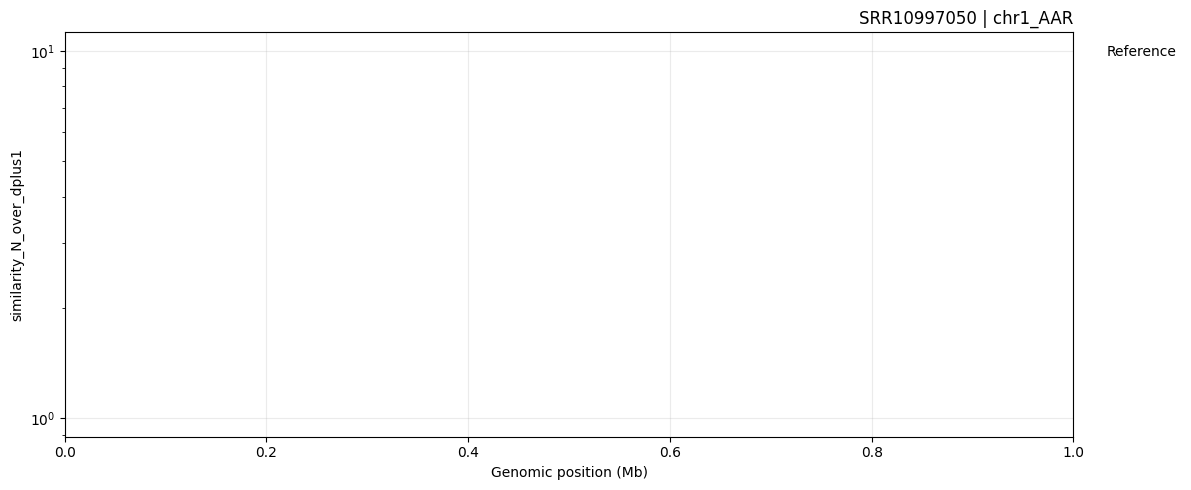

Guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/SRR10997050_chr1_AAR_similarity_N_over_dplus1_refs_lines.png


In [ ]:
import os
import matplotlib.pyplot as plt

# =========================
# CONFIGURACIÓN
# =========================

SAMPLE_NAME = "SRR10997050"   # cambia por tu muestra
CHROM_TARGET = "chr1_AAR"     # cambia por el cromosoma que quieres

METRIC = "similarity_N_over_dplus1"
# METRIC = "divergence_d_over_N"

# =========================
# CARGAR TODAS LAS REFERENCIAS
# =========================

all_dfs = []

for REF_NAME in references:
    try:
        df_ref = load_reference_tables(REF_NAME)
        df_ref["reference"] = REF_NAME
        all_dfs.append(df_ref)
    except Exception as e:
        print(f"[WARN] No se pudo cargar {REF_NAME}: {e}")

all_df = pd.concat(all_dfs, ignore_index=True)

# =========================
# FILTRAR MUESTRA + CROMOSOMA
# =========================

plot_df = all_df[
    (all_df["sample"] == SAMPLE_NAME) &
    (all_df["chrom"] == CHROM_TARGET)
].copy()

print(plot_df[["sample", "reference", "chrom"]].drop_duplicates())

# =========================
# GRAFICAR
# =========================

plt.figure(figsize=(12, 5))

for REF_NAME in sorted(plot_df["reference"].dropna().unique()):
    sub = plot_df[plot_df["reference"] == REF_NAME].sort_values("start_mb")

    plt.plot(
        sub["start_mb"],
        sub[METRIC],
        linewidth=2,
        alpha=0.9,
        label=REF_NAME
    )

plt.title(f"{SAMPLE_NAME} | {CHROM_TARGET}", loc="right")
plt.xlabel("Genomic position (Mb)")
plt.ylabel(METRIC)

if METRIC == "similarity_N_over_dplus1":
    plt.yscale("log")

plt.grid(alpha=0.25)
plt.legend(title="Reference", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()

out_png = os.path.join(
    OUTPUT_DIR,
    f"{SAMPLE_NAME}_{CHROM_TARGET}_{METRIC}_refs_lines.png"
)

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado en:", out_png)

## 8. Resumen comparativo entre referencias

Esta sección colapsa la información de miles de ventanas en una tabla resumen por:

```text
referencia + muestra
```

Es decir, si una muestra fue comparada contra 17 referencias, aparecerá 17 veces:
una fila por cada referencia.

Métricas calculadas:

- `mean_divergence`: promedio de divergencia por ventanas
- `median_divergence`: mediana de divergencia por ventanas
- `mean_similarity`: promedio de similarity
- `median_similarity`: mediana de similarity
- `total_N_sites`: suma total de sitios comparables
- `total_SNPs`: suma total de SNPs

Para decidir qué referencia se parece más a una muestra, normalmente usamos:

```text
menor median_divergence = referencia más parecida
```

In [ ]:
summary_tables = []

for ref in references:
    try:
        df_ref = load_reference_tables(ref)

        summary = (
            df_ref
            .groupby(['reference', 'sample'], as_index=False)
            .agg(
                mean_divergence=('divergence_d_over_N', 'mean'),
                median_divergence=('divergence_d_over_N', 'median'),
                mean_similarity=('similarity_N_over_dplus1', 'mean'),
                median_similarity=('similarity_N_over_dplus1', 'median'),
                total_N_sites=('N_sites', 'sum'),
                total_SNPs=('SNPs_d', 'sum')
            )
        )

        summary_tables.append(summary)

    except FileNotFoundError as e:
        print('[WARN]', e)

if len(summary_tables) == 0:
    raise ValueError("No se cargó ninguna tabla. Revisa RESULTS_ROOT y windows_10kb/.")

summary_all = pd.concat(summary_tables, ignore_index=True)

summary_csv = os.path.join(OUTPUT_DIR, 'multi_reference_summary_by_sample.csv')
summary_all.to_csv(summary_csv, index=False)

print('Resumen guardado en:', summary_csv)
summary_all.head()

Resumen guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/multi_reference_summary_by_sample.csv


,reference,sample,mean_divergence,median_divergence,mean_similarity,median_similarity,total_N_sites,total_SNPs
0,SGD_2010,Scerevisiae_0.001pct_NO,0.037689,0.008708,30.185564,19.0,188044,15475
1,SGD_2010,Scerevisiae_0.1pct_NO,0.042671,0.019355,47.855066,19.0,206932,15775
2,SGD_2010,Scerevisiae_10pct_NO,0.001127,0.000000,6627.782587,10000.0,11673215,13353


## 9. Histograma de divergencia por referencia

Este gráfico responde:

> ¿Cómo se distribuye la divergencia de las muestras contra cada referencia?

Importante:

- la leyenda muestra **referencias**
- el eje X muestra `median_divergence`
- el eje Y muestra número de muestras en cada rango

Este gráfico **no muestra muestras individuales**.  
Sirve para comparar globalmente qué referencias tienden a dar menor o mayor divergencia.

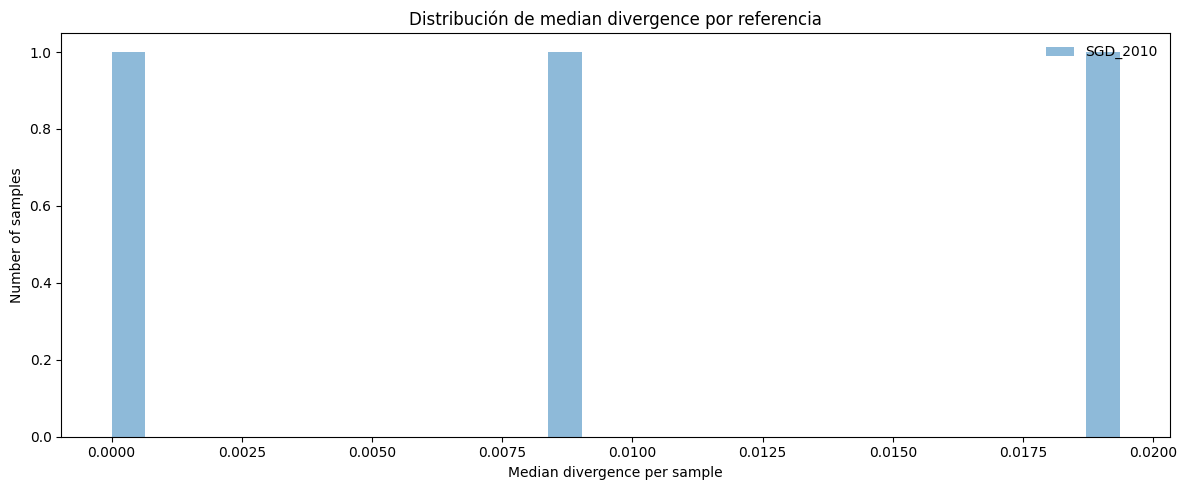

Guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/multi_reference_median_divergence_hist.png


In [ ]:
plt.figure(figsize=(12, 5))

for ref in sorted(summary_all['reference'].unique()):
    vals = summary_all[summary_all['reference'] == ref]['median_divergence'].dropna()
    plt.hist(vals, bins=30, alpha=0.5, label=ref)

plt.xlabel('Median divergence per sample')
plt.ylabel('Number of samples')
plt.title('Distribución de median divergence por referencia')
plt.legend(frameon=False)
plt.tight_layout()

out_png = os.path.join(OUTPUT_DIR, 'multi_reference_median_divergence_hist.png')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

print('Guardado en:', out_png)

## 10. Mejor referencia por muestra

Esta sección busca, para cada muestra, la referencia con menor `median_divergence`.

Interpretación:

```text
menor median_divergence = mayor parecido a esa referencia
```

La salida `best_reference_per_sample.csv` responde:

> ¿A qué referencia se parece más cada muestra?

In [ ]:
best_match = (
    summary_all
    .loc[summary_all.groupby("sample")["median_divergence"].idxmin()]
    .reset_index(drop=True)
    .sort_values("median_divergence")
)

best_csv = os.path.join(OUTPUT_DIR, "best_reference_per_sample.csv")
best_match.to_csv(best_csv, index=False)

print("Guardado en:", best_csv)
best_match.head(10)

Guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/best_reference_per_sample.csv


,reference,sample,mean_divergence,median_divergence,mean_similarity,median_similarity,total_N_sites,total_SNPs
2,SGD_2010,Scerevisiae_10pct_NO,0.001127,0.000000,6627.782587,10000.0,11673215,13353
0,SGD_2010,Scerevisiae_0.001pct_NO,0.037689,0.008708,30.185564,19.0,188044,15475
1,SGD_2010,Scerevisiae_0.1pct_NO,0.042671,0.019355,47.855066,19.0,206932,15775


## 11. Muestra más parecida de todas

Esta celda encuentra la combinación `muestra + referencia` con la menor divergencia global.

Eso responde:

> ¿Cuál es la muestra que más se parece a alguna referencia?

In [ ]:
best_sample = best_match.loc[best_match["median_divergence"].idxmin()]

print("Muestra más similar de todas:")
print(best_sample)

best_sample_name = best_sample["sample"]
best_ref = best_sample["reference"]

print("\nMuestra:", best_sample_name)
print("Referencia más parecida:", best_ref)

Muestra más similar de todas:
reference                        SGD_2010
sample               Scerevisiae_10pct_NO
mean_divergence                  0.001127
median_divergence                     0.0
mean_similarity               6627.782587
median_similarity                 10000.0
total_N_sites                    11673215
total_SNPs                          13353
Name: 2, dtype: object

Muestra: Scerevisiae_10pct_NO
Referencia más parecida: SGD_2010


## 12. Cromosomas más parecidos para la mejor muestra

Ahora analizamos la muestra más similar de todas y preguntamos:

> ¿En qué cromosomas se parece más a su mejor referencia?

Para esto volvemos a los datos por ventana y resumimos por cromosoma.

In [ ]:
df_ref = load_reference_tables(best_ref)
df_sample = df_ref[df_ref["sample"] == best_sample_name].copy()

chrom_summary = (
    df_sample
    .groupby("chrom", as_index=False)
    .agg(
        mean_divergence=("divergence_d_over_N", "mean"),
        median_divergence=("divergence_d_over_N", "median"),
        total_SNPs=("SNPs_d", "sum"),
        total_sites=("N_sites", "sum")
    )
)

chrom_summary = chrom_summary.sort_values(
    "chrom",
    key=lambda x: x.map(natural_chr_key)
)

chrom_summary

,chrom,mean_divergence,median_divergence,total_SNPs,total_sites
0,chr1,0.000409,0.0,94,215622
9,chr2,0.001419,0.0,1129,797697
10,chr3,0.000542,0.0,167,303443
11,chr4,0.001160,0.0,1729,1463953
12,chr5,0.001219,0.0,695,558619
13,chr6,0.000607,0.0,164,262275
14,chr7,0.001455,0.0,1580,1059610
15,chr8,0.000689,0.0,385,535382
16,chr9,0.000600,0.0,258,411798
1,chr10,0.001422,0.0,1037,701931


## 13. Graficar cromosomas de la mejor muestra

Esta gráfica resume qué cromosomas tienen menor o mayor divergencia para la mejor combinación muestra-referencia.

- barras bajas = cromosomas más parecidos
- barras altas = cromosomas más divergentes

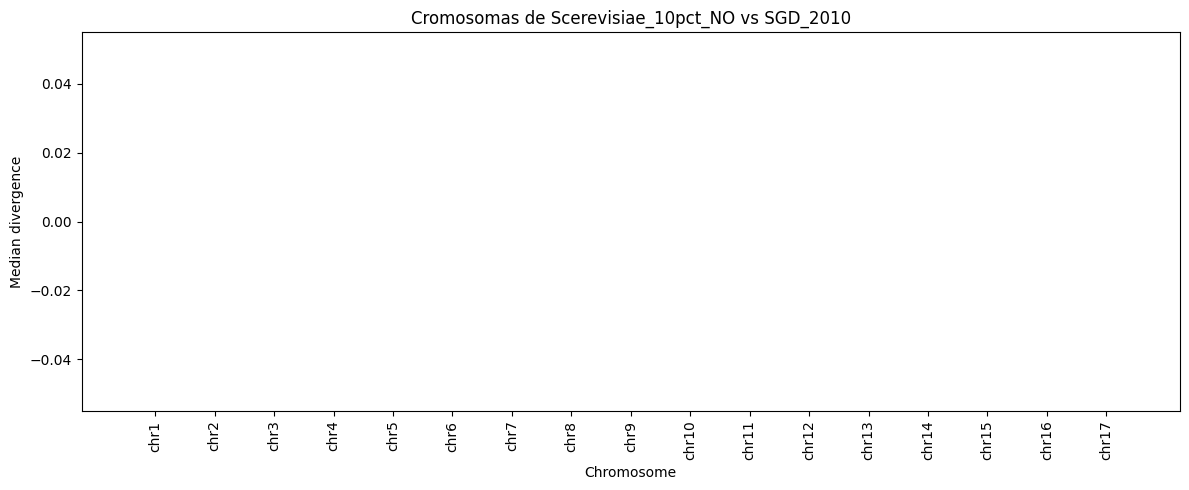

Guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/Scerevisiae_10pct_NO_vs_SGD_2010_chromosome_divergence.png


In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    chrom_summary["chrom"],
    chrom_summary["median_divergence"]
)

plt.xticks(rotation=90)
plt.ylabel("Median divergence")
plt.xlabel("Chromosome")
plt.title(f"Cromosomas de {best_sample_name} vs {best_ref}")
plt.tight_layout()

out_png = os.path.join(
    OUTPUT_DIR,
    f"{best_sample_name}_vs_{best_ref}_chromosome_divergence.png"
)

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado en:", out_png)

## 14. Barplot: mejor referencia por muestra

Esta figura muestra cada muestra con su divergencia mínima.

Interpretación:

- barras bajas = muestra muy parecida a alguna referencia
- barras altas = muestra más diferente incluso contra su mejor referencia

Ojo: si tienes muchas muestras, esta figura puede ser difícil de leer.

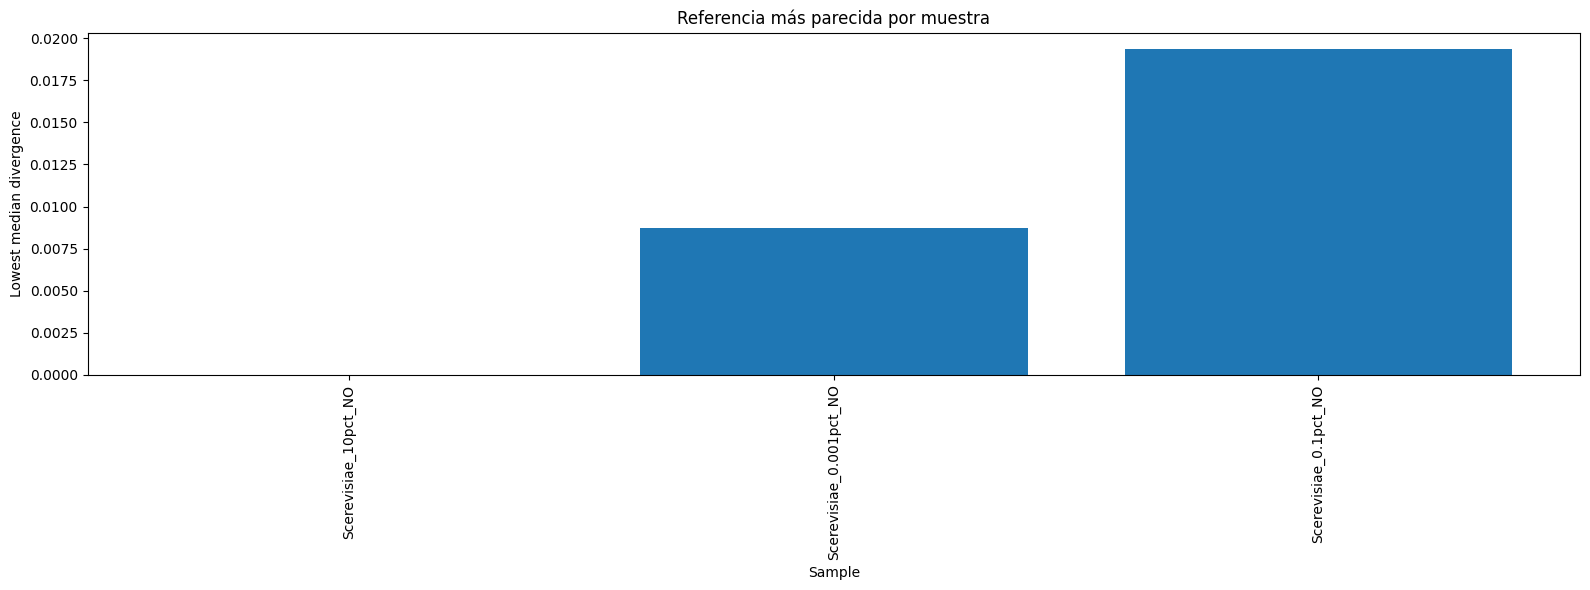

Guardado en: /content/drive/MyDrive/yeast/figures_1C_multi_ref/best_reference_per_sample_barplot.png


In [ ]:
plt.figure(figsize=(16, 6))

plt.bar(
    best_match["sample"],
    best_match["median_divergence"]
)

plt.xticks(rotation=90)
plt.ylabel("Lowest median divergence")
plt.xlabel("Sample")
plt.title("Referencia más parecida por muestra")
plt.tight_layout()

out_png = os.path.join(OUTPUT_DIR, "best_reference_per_sample_barplot.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado en:", out_png)

## 15. Archivos finales más importantes

Al final del notebook, los archivos clave son:

```text
multi_reference_summary_by_sample.csv
best_reference_per_sample.csv
```

### `multi_reference_summary_by_sample.csv`

Contiene una fila por cada combinación:

```text
referencia + muestra
```

Sirve para comparar todas las referencias contra todas las muestras.

### `best_reference_per_sample.csv`

Contiene una fila por muestra:

```text
muestra → referencia más parecida
```

Esta es la tabla más útil para interpretación biológica inicial.

### Recomendación de interpretación

Usa principalmente:

```text
median_divergence
```

porque es más interpretable que `similarity`:

- `0.001` = 0.1% de diferencia en las posiciones comparables
- `0.01` = 1% de diferencia
- `0.05` = 5% de diferencia

Recuerda: en las gráficas por ventana, la divergencia se interpreta localmente, ventana por ventana.